In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import sctrial as st
pd.options.mode.chained_assignment = None


# Example: Immunotherapy Response in Melanoma
### Dataset: Sade-Feldman et al. (Cell 2018)

**Background:** Sade-Feldman et al. (Cell 2018) profiled immune cells from patients before and during anti-PD-1 therapy. They identified signatures linked to response.

**Data Source:** [GEO GSE120575](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE120575)


## 1. Load Actual Data


In [2]:
from pathlib import Path
from io import StringIO
import gzip
import re


def _resolve_dir_with_files(p: str, required_files) -> Path:
    path = Path(p)
    if path.is_absolute():
        if all((path / f).exists() for f in required_files):
            return path
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / path
        if all((cand / f).exists() for f in required_files):
            return cand
    return path


def load_sade_feldman(
    data_dir="data/sade_feldman",
    processed_name="sade_feldman_processed.h5ad",
    max_cells=3000,
    seed=42,
):
    data_dir = _resolve_dir_with_files(
        data_dir,
        [
            "GSE120575_Sade_Feldman_melanoma_single_cells_TPM_GEO.txt.gz",
            "GSE120575_patient_ID_single_cells.txt.gz",
        ],
    )
    processed_path = data_dir.parent / "processed" / processed_name

    if processed_path.exists():
        adata = sc.read_h5ad(processed_path)
        print(f"Loaded processed Sade-Feldman dataset: {adata.n_obs} cells, {adata.n_vars} genes")
        print("Processed file:", processed_path)
        print("Responses:", adata.obs["response"].unique())
        print("Visits:", adata.obs["visit"].unique())
        print("Cell types:", adata.obs["cell_type"].unique())
        return adata

    tpm_path = data_dir / "GSE120575_Sade_Feldman_melanoma_single_cells_TPM_GEO.txt.gz"
    meta_path = data_dir / "GSE120575_patient_ID_single_cells.txt.gz"

    for p in [tpm_path, meta_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing file: {p}")

    # Parse TPM matrix with two header rows
    with gzip.open(tpm_path, "rt") as f:
        header1 = f.readline().strip().split("	")
        header2 = f.readline().strip().split("	")
        if len(header1) != len(header2):
            raise ValueError("TPM file header rows have inconsistent lengths.")
        # header1 contains sample IDs
        sample_ids = header1
        time_labels = header2
        data = f.read()

    df = pd.read_csv(StringIO(data), sep="	", header=None)
    # Drop trailing all-NaN column if present
    if df.iloc[:, -1].isna().all():
        df = df.iloc[:, :-1]

    genes = df.iloc[:, 0].astype(str).values
    mat = df.iloc[:, 1:]
    if mat.shape[1] != len(sample_ids):
        raise ValueError(f"TPM matrix columns ({mat.shape[1]}) != sample IDs ({len(sample_ids)}).")
    mat.columns = sample_ids

    # Metadata (skip header comments)
    meta = pd.read_csv(meta_path, sep="	", skiprows=19, encoding="latin1")
    meta = meta.rename(columns={
        "title": "sample_id",
        "characteristics: patinet ID (Pre=baseline; Post= on treatment)": "patient_raw",
        "characteristics: response": "response",
    })
    meta["sample_id"] = meta["sample_id"].astype(str)
    meta = meta.dropna(subset=["sample_id"]).copy()

    # Keep only real sample rows
    meta = meta[meta["sample_id"].str.match(r"^[A-Z]\d+_P\d+_M\d+")].copy()
    meta = meta[meta["response"].isin(["Responder", "Non-responder"])].copy()

    # Build visit/participant from patient_raw (e.g., Pre_P1, Post_P1_2)
    meta["visit"] = meta["patient_raw"].astype(str).str.split("_").str[0]
    meta["participant_id"] = meta["patient_raw"].astype(str).str.extract(r"(P\d+)")

    time_map = dict(zip(sample_ids, time_labels))
    meta["time_label"] = meta["sample_id"].map(time_map)

    meta = meta.set_index("sample_id")
    meta = meta.loc[[s for s in sample_ids if s in meta.index]].copy()

    # Build AnnData
    adata = sc.AnnData(X=mat.T.loc[meta.index].values)
    adata.obs = meta
    adata.var_names = genes

    # Add coarse cell type (dataset is single-cell melanoma; keep as T cell for example)
    adata.obs["cell_type"] = "T cell"

    # Subsample for speed
    rng = np.random.default_rng(seed)
    if max_cells is not None and adata.n_obs > max_cells:
        keep = rng.choice(adata.obs_names, size=max_cells, replace=False)
        adata = adata[keep].copy()

    processed_path.parent.mkdir(parents=True, exist_ok=True)
    adata.write_h5ad(processed_path)
    print("Saved processed file:", processed_path)

    print(f"Loaded Sade-Feldman dataset: {adata.n_obs} cells, {adata.n_vars} genes")
    print("Responses:", adata.obs["response"].unique())
    print("Visits:", adata.obs["visit"].unique())
    print("Cell types:", adata.obs["cell_type"].unique())

    return adata

adata = load_sade_feldman()


Loaded processed Sade-Feldman dataset: 3000 cells, 55737 genes
Processed file: /Users/omarm/Documents/Research/projects/sc-trialdiff/data/processed/sade_feldman_processed.h5ad
Responses: ['Responder', 'Non-responder']
Categories (2, object): ['Non-responder', 'Responder']
Visits: ['Pre', 'Post']
Categories (2, object): ['Post', 'Pre']
Cell types: ['T cell']
Categories (1, object): ['T cell']


## 2. DiD and Visuals


Paired participants (Pre vs Post): 10
Between-arm (OLS) at Pre:


,beta_arm,p_arm,n_units,FDR_arm
feature,,,,
ms_Cytotoxicity,-1.215318,0.005909,18,0.011819
ms_Exhaustion,-0.796484,0.093464,18,0.093464


Between-arm (OLS) at Post:


,beta_arm,p_arm,n_units,FDR_arm
feature,,,,
ms_Cytotoxicity,-0.567182,0.331988,17,0.331988
ms_Exhaustion,-0.796219,0.166620,17,0.331988


Within-arm for Non-responder:

...

,beta_time,p_time,n_units,FDR_time
feature,,,,
ms_Cytotoxicity,0.809097,NaN,2,NaN
ms_Exhaustion,0.467430,NaN,2,NaN


DiD (participant_visit):


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,FDR_DiD
feature,,,,,,,
ms_Cytotoxicity,-0.683572,NaN,NaN,0.515575,NaN,10,NaN
ms_Exhaustion,-1.352457,NaN,NaN,0.994862,NaN,10,NaN


DiD (cell-level):


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,FDR_DiD
feature,,,,,,,
ms_Exhaustion,-0.535937,0.180133,0.002928,0.358282,0.000583,10,0.005855
ms_Cytotoxicity,-0.267365,0.295835,0.366120,0.135460,0.266009,10,0.366120


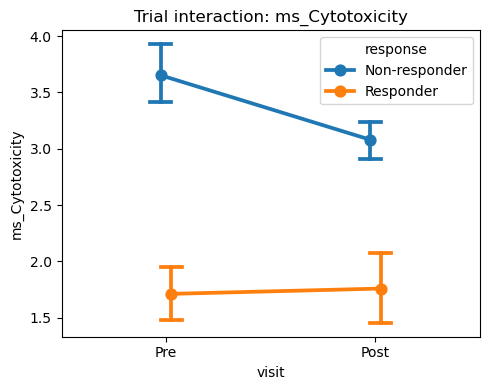

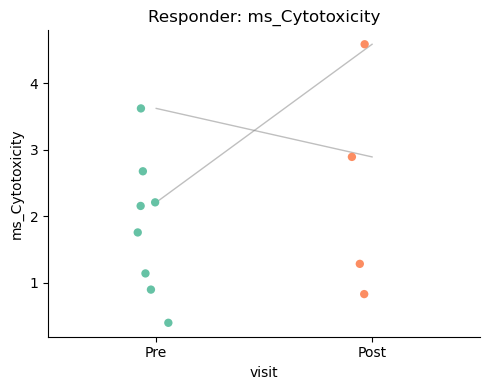

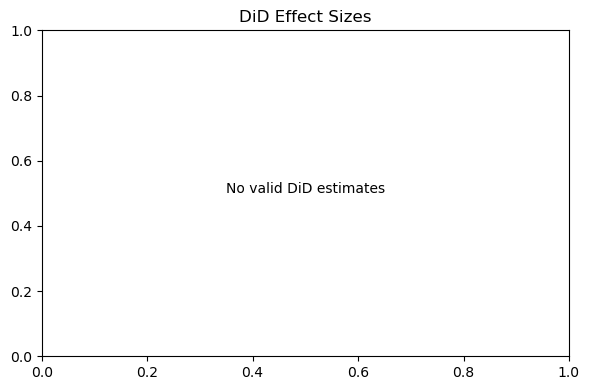

In [3]:
available = set(adata.var_names)
gene_sets = {
    "Cytotoxicity": [g for g in ["GZMB", "PRF1", "GNLY", "IFNG"] if g in available],
    "Exhaustion": [g for g in ["LAG3", "PDCD1", "HAVCR2", "TIGIT"] if g in available]
}
gene_sets = {k: v for k, v in gene_sets.items() if len(v) >= 2}
if gene_sets:
    adata = st.score_gene_sets(adata, gene_sets, method="mean", prefix="ms_")
else:
    print("No gene sets matched this dataset; skipping module scoring.")

features = [f for f in adata.obs.columns if f.startswith("ms_")]
if not features:
    print("No module scores available; skipping analysis.")
else:
    design = st.TrialDesign(
        participant_col="participant_id",
        visit_col="visit",
        arm_col="response",
        arm_treated="Responder",
        arm_control="Non-responder",
        celltype_col="cell_type",
    )

    visits = [v for v in ["Pre", "Post"] if v in adata.obs["visit"].unique()]
    paired = adata.obs.groupby("participant_id")["visit"].nunique()
    n_paired = int((paired >= 2).sum())
    print(f"Paired participants (Pre vs Post): {n_paired}")

    # Between-arm comparisons at baseline and post
    for v in visits:
        res_ols = st.between_arm_comparison(
            adata,
            visit=v,
            features=features,
            design=design,
            aggregate="participant_visit",
            method="ols",
        )
        print(f"Between-arm (OLS) at {v}:")
        if not res_ols.empty:
            display(res_ols.set_index("feature"))

    # Within-arm comparisons (paired)
    if n_paired >= 4 and len(visits) == 2:
        for arm in [design.arm_control, design.arm_treated]:
            res_within = st.within_arm_comparison(
                adata,
                arm=arm,
                features=features,
                design=design,
                visits=tuple(visits),
                aggregate="participant_visit",
            )
            print(f"Within-arm for {arm}:")
            if not res_within.empty:
                display(res_within.set_index("feature"))

    # DiD with two aggregation modes
    did = None
    if n_paired >= 4 and len(visits) == 2:
        did = st.did_table(
            adata,
            features=features,
            design=design,
            visits=tuple(visits),
            aggregate="participant_visit",
        )
        print("DiD (participant_visit):")
        if not did.empty:
            display(did.set_index("feature"))

        did_cell = st.did_table(
            adata,
            features=features,
            design=design,
            visits=tuple(visits),
            aggregate="cell",
        )
        print("DiD (cell-level):")
        if not did_cell.empty:
            display(did_cell.set_index("feature"))

    # Plots
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_trial_interaction(adata, features[0], design=design, visits=tuple(visits), ax=ax)
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_within_arm_comparison(
        adata,
        arm=design.arm_treated,
        feature=features[0],
        design=design,
        visits=tuple(visits),
        plot_type="paired",
        ax=ax,
    )
    plt.tight_layout(); plt.show()

    if did is not None and not did.empty:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        st.plot_did_forest(did, ax=ax)
        plt.tight_layout(); plt.show()
